# Classificação de Popularidade de Livros — Goodreads 100k

## Contexto do Problema

Este notebook resolve um problema de **classificação supervisionada** sobre o dataset **Goodreads Books 100k**, disponível publicamente no Kaggle.

### Problema
Dado um conjunto de atributos de um livro (avaliação média e número de páginas), queremos prever sua **popularidade** — classificada em três categorias com base no número de avaliações do conjunto de treino:

| Classe | Critério |
|--------|----------|
| **Alta** | `ratings_count` ≥ percentil 75 do treino |
| **Média** | percentil 25 ≤ `ratings_count` < percentil 75 do treino |
| **Baixa** | `ratings_count` < percentil 25 do treino |

### Por que este dataset?
O Goodreads Books 100k contém metadados reais de mais de 100.000 livros. É um dataset diversificado, não utilizado na disciplina, e que permite explorar todas as etapas do pipeline de ML supervisionado.

### Etapas do Pipeline
1. Carga e exploração (EDA)
2. Pré-processamento e limpeza
3. Separação treino/teste — **antes de qualquer transformação ou derivação**
4. Criação do target — **com percentis calculados apenas no treino**
5. Seleção de features — **sem incluir a coluna que gerou o target**
6. Normalização e padronização dentro de Pipelines
7. Modelagem: KNN, Árvore de Classificação, Naive Bayes, Regressão Logística
8. Otimização de hiperparâmetros (GridSearchCV + Cross-Validation)
9. Avaliação e comparação de modelos
10. Exportação do melhor modelo
11. Exportação dos artefatos para o sistema de recomendação

## 0. Instalação e Importações

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

In [26]:
import os
import json
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## 1. Carga dos Dados

In [27]:
df_raw = pd.read_csv('https://github.com/stephaniefay/s4-mvp/releases/download/csv/books.csv', on_bad_lines='skip')

print(f'Shape: {df_raw.shape}')
print(f'Colunas: {df_raw.columns.tolist()}')
df_raw.head()

Shape: (100000, 13)
Colunas: ['author', 'bookformat', 'desc', 'genre', 'img', 'isbn', 'isbn13', 'link', 'pages', 'rating', 'reviews', 'title', 'totalratings']


,author,bookformat,desc,genre,img,isbn,isbn13,link,pages,rating,reviews,title,totalratings
0,Laurence M. Hauptman,Hardcover,Reveals that several hundred thousand Indians ...,"History,Military History,Civil War,American Hi...",https://i.gr-assets.com/images/S/compressed.ph...,002914180X,9.78E+12,https://goodreads.com/book/show/1001053.Betwee...,0,3.52,5,Between Two Fires: American Indians in the Civ...,33
1,"Charlotte Fiell,Emmanuelle Dirix",Paperback,Fashion Sourcebook - 1920s is the first book i...,"Couture,Fashion,Historical,Art,Nonfiction",https://i.gr-assets.com/images/S/compressed.ph...,1906863482,9.78E+12,https://goodreads.com/book/show/10010552-fashi...,576,4.51,6,Fashion Sourcebook 1920s,41
2,Andy Anderson,Paperback,The seminal history and analysis of the Hungar...,"Politics,History",https://i.gr-assets.com/images/S/compressed.ph...,948984147,9.78E+12,https://goodreads.com/book/show/1001077.Hungar...,124,4.15,2,Hungary 56,26
3,Carlotta R. Anderson,Hardcover,"""All-American Anarchist"" chronicles the life a...","Labor,History",https://i.gr-assets.com/images/S/compressed.ph...,814327079,9.78E+12,https://goodreads.com/book/show/1001079.All_Am...,324,3.83,1,All-American Anarchist: Joseph A. Labadie and ...,6
4,Jean Leveille,NaN,"Aujourdâ€™hui, lâ€™oiseau nous invite Ã sa ta...",NaN,https://i.gr-assets.com/images/S/compressed.ph...,2761920813,NaN,https://goodreads.com/book/show/10010880-les-o...,177,4.00,1,Les oiseaux gourmands,1


## 2. Análise Exploratória (EDA)

Investigamos a estrutura do dataset antes de qualquer transformação. A EDA tem propósito exclusivamente descritivo — nenhuma estatística calculada aqui será reutilizada no treinamento.

In [28]:
print('=== Tipos de dados ===')
print(df_raw.dtypes)
print('\n=== Valores ausentes (%) ===')
print((df_raw.isnull().mean() * 100).round(2).sort_values(ascending=False))

=== Tipos de dados ===
author           object
bookformat       object
desc             object
genre            object
img              object
isbn             object
isbn13           object
link             object
pages             int64
rating          float64
reviews           int64
title            object
totalratings      int64
dtype: object

=== Valores ausentes (%) ===
isbn            14.48
isbn13          11.43
genre           10.47
desc             6.77
bookformat       3.23
img              3.04
author           0.00
link             0.00
pages            0.00
rating           0.00
reviews          0.00
title            0.00
totalratings     0.00
dtype: float64


In [29]:
df_raw.describe()

,pages,rating,reviews,totalratings
count,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,255.010240,3.833055,181.528450,2.990764e+03
std,367.913582,0.621237,1449.451229,3.635338e+04
min,0.000000,0.000000,0.000000,0.000000e+00
25%,135.000000,3.660000,3.000000,3.100000e+01
50%,240.000000,3.910000,15.000000,1.460000e+02
75%,336.000000,4.140000,67.000000,7.440000e+02
max,70000.000000,5.000000,158776.000000,3.819326e+06


## 3. Pré-processamento

Padronizamos os nomes das colunas e fazemos as conversões de tipo. A identificação das colunas usa listas de palavras-chave ordenadas da mais específica para a mais genérica, evitando conflitos de nomenclatura.

In [30]:
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

def encontrar_coluna(dataframe, palavras_chave):
    """
    Retorna a primeira coluna cujo nome contém alguma das palavras-chave.
    A lista deve ser ordenada da mais específica para a mais genérica.
    """
    for palavra in palavras_chave:
        matches = [c for c in dataframe.columns if palavra in c]
        if matches:
            return matches[0]
    return None

# Todas as colunas disponíveis após padronização — inspecione se houver erro
print('Colunas disponíveis no dataset:')
print(df.columns.tolist())
print()

# Palavras-chave ordenadas da mais específica para a mais genérica.
# Inclui variantes reais do dataset Goodreads 100k (ex: 'totalratings', 'rating')
COL_TITULO  = encontrar_coluna(df, ['book_title', 'title', 'book_name', 'name'])
COL_AUTOR   = encontrar_coluna(df, ['book_author', 'author_name', 'author'])
COL_RATING  = encontrar_coluna(df, ['average_rating', 'avg_rating', 'mean_rating', 'rating'])
COL_COUNT   = encontrar_coluna(df, ['ratings_count', 'num_ratings', 'total_ratings',
                                    'rating_count', 'totalratings', 'numratings'])
COL_PAGINAS = encontrar_coluna(df, ['num_pages', 'number_of_pages', 'pages'])
COL_LINK    = encontrar_coluna(df, ['link', 'url', 'goodreads_link']) # Adicionado aqui para ser usado em `colunas`

print(f'Título  : {COL_TITULO}')
print(f'Autor   : {COL_AUTOR}')
print(f'Rating  : {COL_RATING}')
print(f'Count   : {COL_COUNT}')
print(f'Páginas : {COL_PAGINAS}')
print(f'Link    : {COL_LINK}')

if COL_RATING is None or COL_COUNT is None:
    raise ValueError(
        f'Não foi possível identificar automaticamente as colunas obrigatórias.\n'
    )

Colunas disponíveis no dataset:
['author', 'bookformat', 'desc', 'genre', 'img', 'isbn', 'isbn13', 'link', 'pages', 'rating', 'reviews', 'title', 'totalratings']

Título  : title
Autor   : author
Rating  : rating
Count   : totalratings
Páginas : pages
Link    : link


In [31]:
# Seleção e conversão de tipos
colunas = [c for c in [COL_TITULO, COL_AUTOR, COL_RATING, COL_COUNT, COL_PAGINAS, COL_LINK] if c is not None]
df = df[colunas].copy()

df[COL_RATING] = pd.to_numeric(df[COL_RATING], errors='coerce')
df[COL_COUNT]  = pd.to_numeric(df[COL_COUNT],  errors='coerce')
if COL_PAGINAS:
    df[COL_PAGINAS] = pd.to_numeric(df[COL_PAGINAS], errors='coerce')
    # Nulos de páginas são preenchidos APÓS o split, com a mediana do treino

# Remove nulos nas colunas obrigatórias e registros inválidos
df = df.dropna(subset=[COL_RATING, COL_COUNT])
df = df[df[COL_COUNT] > 0].reset_index(drop=True)

print(f'Shape após limpeza: {df.shape}')

Shape após limpeza: (98438, 6)


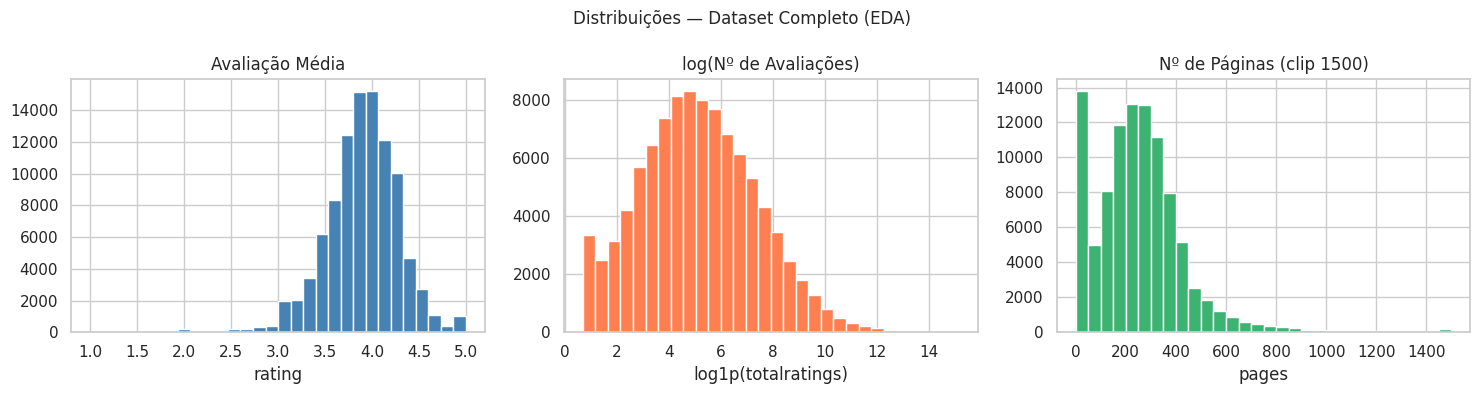

In [8]:
# Visualizações EDA — apenas descritivas, sem derivar nenhuma feature
ncols = 3 if COL_PAGINAS else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))

df[COL_RATING].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Avaliação Média')
axes[0].set_xlabel(COL_RATING)

np.log1p(df[COL_COUNT]).hist(ax=axes[1], bins=30, color='coral', edgecolor='white')
axes[1].set_title('log(Nº de Avaliações)')
axes[1].set_xlabel(f'log1p({COL_COUNT})')

if COL_PAGINAS:
    df[COL_PAGINAS].clip(0, 1500).hist(ax=axes[2], bins=30, color='mediumseagreen', edgecolor='white')
    axes[2].set_title('Nº de Páginas (clip 1500)')
    axes[2].set_xlabel(COL_PAGINAS)

plt.suptitle('Distribuições — Dataset Completo (EDA)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_distribuicoes.png', dpi=120)
plt.show()

## 4. Separação Treino/Teste (Holdout)

O holdout é realizado **antes** de qualquer derivação de target ou feature. Isso é essencial por dois motivos:

1. Os **percentis** que definem `popularidade` precisam ser calculados só no treino
2. A **mediana de páginas** usada para imputação também precisa vir só do treino

Como o target ainda não existe, estratificamos por quartis de `average_rating` para garantir distribuição equilibrada.

In [32]:
# Estratificação auxiliar por quartil de rating (target ainda não existe)
rating_quartil = pd.qcut(df[COL_RATING], q=4, labels=False, duplicates='drop')

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=rating_quartil
)

df_train = df_train.copy().reset_index(drop=True)
df_test  = df_test.copy().reset_index(drop=True)

print(f'Treino : {len(df_train):>7,} amostras ({len(df_train)/len(df)*100:.1f}%)')
print(f'Teste  : {len(df_test):>7,} amostras ({len(df_test)/len(df)*100:.1f}%)')

Treino :  78,750 amostras (80.0%)
Teste  :  19,688 amostras (20.0%)


## 5. Criação do Target e Seleção de Features

### Target — Popularidade

Os percentis são calculados **exclusivamente sobre o treino** e depois aplicados ao teste.

### Features de classificação

As features escolhidas são **genuinamente independentes** do target:

| Feature | Descrição | Por que usar |
|---|---|---|
| `average_rating` | Avaliação média (0–5) | Atributo intrínseco do livro, não derivado de `ratings_count` |
| `pages_clip` | Nº de páginas (clip 2000) | Atributo intrínseco do livro, não derivado de `ratings_count` |

> **Por que `ratings_count` e suas derivadas (`log_count`, `rating_x_log`) estão ausentes?**
>
> O target `popularidade` é uma transformação direta e determinística de `ratings_count` via percentis. Incluir `ratings_count` — ou qualquer função monotônica dela como `log(ratings_count)` — como feature equivale a revelar o target ao modelo. A Árvore de Decisão, por exemplo, consegue reconstruir a classificação perfeita com apenas um nó de decisão (`log_count >= threshold`), resultando em F1 = 1.0 — um indicador claro de leakage. Para uma tarefa de classificação honesta, as features devem ser atributos que descrevem o livro independentemente de quão popular ele é.

In [33]:
# Parâmetros aprendidos EXCLUSIVAMENTE no treino
p25 = df_train[COL_COUNT].quantile(0.25)
p75 = df_train[COL_COUNT].quantile(0.75)

# Mediana de páginas do treino — usada para imputar nulos no treino E no teste
if COL_PAGINAS:
    mediana_paginas = df_train[COL_PAGINAS].median()
else:
    mediana_paginas = None

print(f'Percentil 25 (treino): {p25:,.0f} avaliações')
print(f'Percentil 75 (treino): {p75:,.0f} avaliações')
if mediana_paginas:
    print(f'Mediana páginas      : {mediana_paginas:.0f}')

Percentil 25 (treino): 34 avaliações
Percentil 75 (treino): 762 avaliações
Mediana páginas      : 240


In [34]:
def classificar_popularidade(n, p25, p75):
    """Classifica a popularidade usando os percentis do treino."""
    if n >= p75:   return 'Alta'
    elif n >= p25: return 'Média'
    else:          return 'Baixa'


def aplicar_target_e_features(df_split, p25, p75, mediana_paginas,
                              col_count, col_rating, col_paginas):
    """
    Cria o target e as features de um split.

    Parâmetros
    ----------
    Todos os parâmetros de transformação (p25, p75, mediana_paginas)
    são calculados no treino e passados explicitamente — nunca recalculados
    a partir do split atual.

    Retorna
    -------
    df_out : DataFrame com target e features adicionados
    features : lista com os nomes das features de classificação
    """
    d = df_split.copy()

    # Target
    d['popularidade'] = d[col_count].apply(
        lambda n: classificar_popularidade(n, p25, p75)
    )

    # Features — apenas atributos independentes do target
    features = [col_rating]

    if col_paginas and mediana_paginas is not None:
        d[col_paginas] = d[col_paginas].fillna(mediana_paginas)  # mediana DO TREINO
        d['pages_clip'] = d[col_paginas].clip(0, 2000)
        features.append('pages_clip')

    return d, features


df_train, FEATURES = aplicar_target_e_features(
    df_train, p25, p75, mediana_paginas, COL_COUNT, COL_RATING, COL_PAGINAS
)
df_test, _ = aplicar_target_e_features(
    df_test,  p25, p75, mediana_paginas, COL_COUNT, COL_RATING, COL_PAGINAS
)

print('Features de classificação:', FEATURES)
print('\nDistribuição das classes — Treino:')
print(df_train['popularidade'].value_counts())
print('\nDistribuição das classes — Teste:')
print(df_test['popularidade'].value_counts())

Features de classificação: ['rating', 'pages_clip']

Distribuição das classes — Treino:
popularidade
Média    39492
Alta     19697
Baixa    19561
Name: count, dtype: int64

Distribuição das classes — Teste:
popularidade
Média    9778
Alta     5019
Baixa    4891
Name: count, dtype: int64


In [35]:
# Verificação de sanidade: rating NÃO deve ser capaz de separar as classes perfeitamente
# (caso contrário ainda haveria leakage via outro caminho)
print('Estatísticas de average_rating por classe (treino):')
print(df_train.groupby('popularidade')[COL_RATING].describe().round(3))

Estatísticas de average_rating por classe (treino):
                count   mean    std   min   25%   50%   75%   max
popularidade                                                     
Alta          19697.0  3.949  0.277  2.51  3.78  3.96  4.14  4.79
Baixa         19561.0  3.873  0.559  1.00  3.55  3.93  4.22  5.00
Média         39492.0  3.878  0.337  1.31  3.66  3.89  4.11  4.95


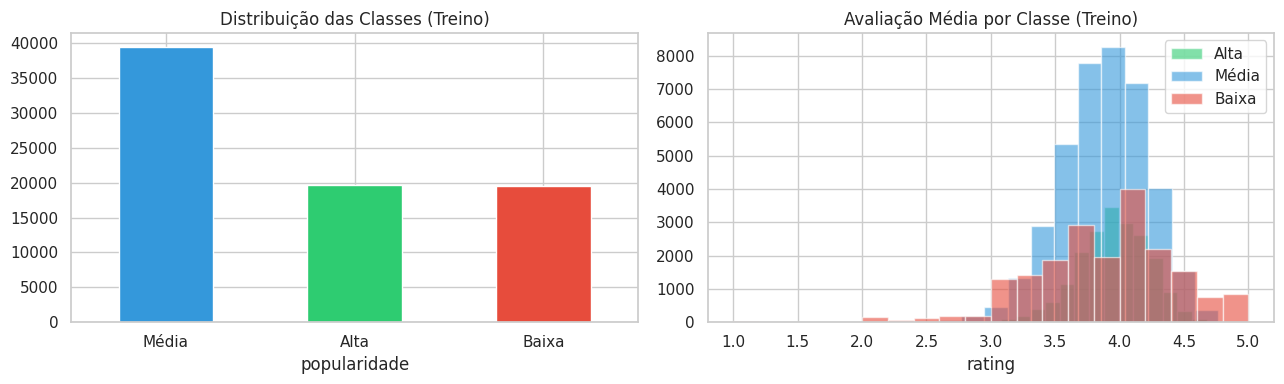

In [36]:
# Visualização das classes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cores = {'Alta': '#2ecc71', 'Média': '#3498db', 'Baixa': '#e74c3c'}

contagem = df_train['popularidade'].value_counts()
contagem.plot(
    kind='bar', ax=axes[0],
    color=[cores[c] for c in contagem.index],
    edgecolor='white'
)
axes[0].set_title('Distribuição das Classes (Treino)')
axes[0].tick_params(axis='x', rotation=0)

for pop, cor in cores.items():
    subset = df_train[df_train['popularidade'] == pop][COL_RATING]
    subset.hist(ax=axes[1], bins=20, alpha=0.6, label=pop, color=cor, edgecolor='white')
axes[1].set_title('Avaliação Média por Classe (Treino)')
axes[1].set_xlabel(COL_RATING)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_classes.png', dpi=120)
plt.show()

In [37]:
# Extração de X e y
X_train = df_train[FEATURES].values
y_train = df_train['popularidade'].values

X_test  = df_test[FEATURES].values
y_test  = df_test['popularidade'].values

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (78750, 2)
X_test  : (19688, 2)


## 6. Modelagem com Pipelines

Cada algoritmo é encapsulado em um **Pipeline** do Scikit-Learn. O scaler é ajustado apenas nos dados de treino durante o `fit()`, nunca vendo os dados de teste — uma segunda camada de proteção contra leakage.

O SVM foi substituído pela **Regressão Logística**, que apresenta desempenho competitivo com dados tabulares, tempo de execução significativamente menor e maior interpretabilidade.

| Algoritmo | Scaler | Justificativa |
|---|---|---|
| KNN | StandardScaler | Muito sensível à escala das features |
| Árvore de Classificação | StandardScaler | Invariante à escala, mantido por consistência |
| Naive Bayes (Gaussiano) | MinMaxScaler | GaussianNB exige valores ≥ 0 |
| Regressão Logística | StandardScaler | Converge mais rápido com dados padronizados |

In [38]:
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Árvore': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', GaussianNB())
    ]),
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=1000))
    ])
}

print('Pipelines definidos:', list(pipelines.keys()))

Pipelines definidos: ['KNN', 'Árvore', 'Naive Bayes', 'Regressão Logística']


## 7. Otimização de Hiperparâmetros

Usamos **GridSearchCV** com **Stratified K-Fold (5 folds)** para buscar os melhores hiperparâmetros de cada algoritmo. A métrica de otimização é o **F1-macro**, adequada para problemas multiclasse. O GridSearchCV é ajustado exclusivamente sobre `X_train`/`y_train`.

In [39]:
param_grids = {
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 11, 15],
        'clf__weights':     ['uniform', 'distance'],
        'clf__metric':      ['euclidean', 'manhattan']
    },
    'Árvore': {
        'clf__max_depth':        [3, 5, 10, 20, None],
        'clf__min_samples_leaf': [1, 5, 10, 20],
        'clf__criterion':        ['gini', 'entropy']
    },
    'Naive Bayes': {
        'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'Regressão Logística': {
        'clf__C':      [0.01, 0.1, 1, 10],
        'clf__solver': ['lbfgs', 'saga']
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [40]:
melhores_modelos = {}
resultados_cv    = {}

for nome, pipeline in pipelines.items():
    print(f'\n Otimizando: {nome}...')
    grid = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grids[nome],
        cv         = cv,
        scoring    = 'f1_macro',
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)
    melhores_modelos[nome] = grid.best_estimator_
    resultados_cv[nome]    = grid.best_score_
    print(f'    Melhor F1-macro (CV) : {grid.best_score_:.4f}')
    print(f'    Hiperparâmetros      : {grid.best_params_}')


 Otimizando: KNN...
    Melhor F1-macro (CV) : 0.4865
    Hiperparâmetros      : {'clf__metric': 'manhattan', 'clf__n_neighbors': 11, 'clf__weights': 'uniform'}

 Otimizando: Árvore...
    Melhor F1-macro (CV) : 0.4998
    Hiperparâmetros      : {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 20}

 Otimizando: Naive Bayes...
    Melhor F1-macro (CV) : 0.3310
    Hiperparâmetros      : {'clf__var_smoothing': 1e-09}

 Otimizando: Regressão Logística...
    Melhor F1-macro (CV) : 0.2315
    Hiperparâmetros      : {'clf__C': 1, 'clf__solver': 'lbfgs'}


## 8. Avaliação e Comparação dos Modelos

Avaliamos o desempenho de cada modelo no **conjunto de teste** — dados que não influenciaram nenhuma decisão do pipeline. Uma diferença pequena entre CV e Teste indica boa generalização, sem overfitting.

In [41]:
resultados_teste = {}

for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    resultados_teste[nome] = {'accuracy': acc, 'f1_macro': f1, 'y_pred': y_pred}
    print(f'\n══ {nome} ══')
    print(f'  Acurácia : {acc:.4f}  |  F1-macro : {f1:.4f}')
    print(classification_report(y_test, y_pred))


══ KNN ══
  Acurácia : 0.5247  |  F1-macro : 0.4787
              precision    recall  f1-score   support

        Alta       0.37      0.27      0.31      5019
       Baixa       0.58      0.46      0.51      4891
       Média       0.56      0.69      0.62      9778

    accuracy                           0.52     19688
   macro avg       0.50      0.47      0.48     19688
weighted avg       0.51      0.52      0.51     19688


══ Árvore ══
  Acurácia : 0.5482  |  F1-macro : 0.4948
              precision    recall  f1-score   support

        Alta       0.39      0.25      0.31      5019
       Baixa       0.63      0.47      0.54      4891
       Média       0.56      0.74      0.64      9778

    accuracy                           0.55     19688
   macro avg       0.53      0.49      0.49     19688
weighted avg       0.54      0.55      0.53     19688


══ Naive Bayes ══
  Acurácia : 0.5228  |  F1-macro : 0.3289
              precision    recall  f1-score   support

        Alta 

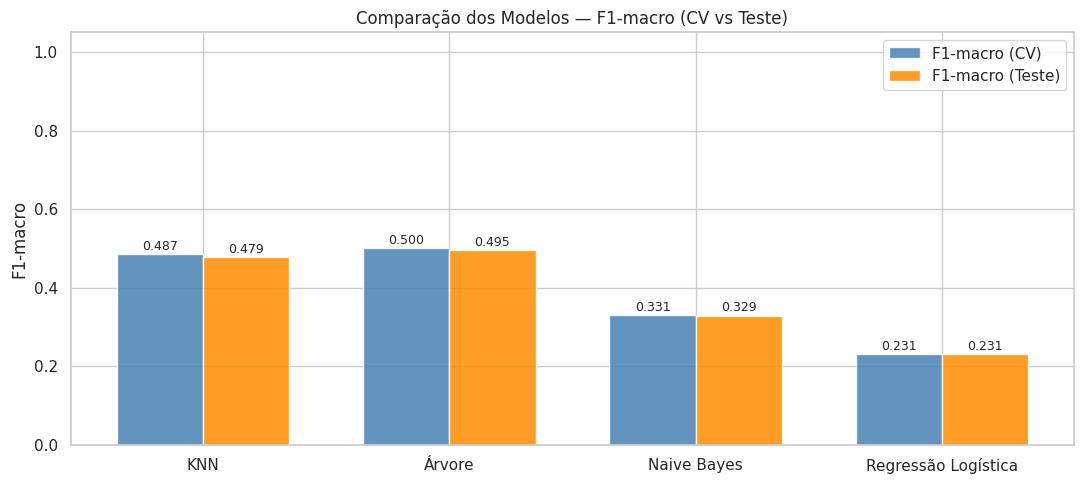

In [42]:
# Gráfico comparativo CV vs Teste
nomes    = list(melhores_modelos.keys())
f1_cv    = [resultados_cv[n] for n in nomes]
f1_teste = [resultados_teste[n]['f1_macro'] for n in nomes]

x, width = np.arange(len(nomes)), 0.35
fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - width/2, f1_cv,    width, label='F1-macro (CV)',    color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, f1_teste, width, label='F1-macro (Teste)', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-macro')
ax.set_title('Comparação dos Modelos — F1-macro (CV vs Teste)')
ax.legend()

for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=120)
plt.show()

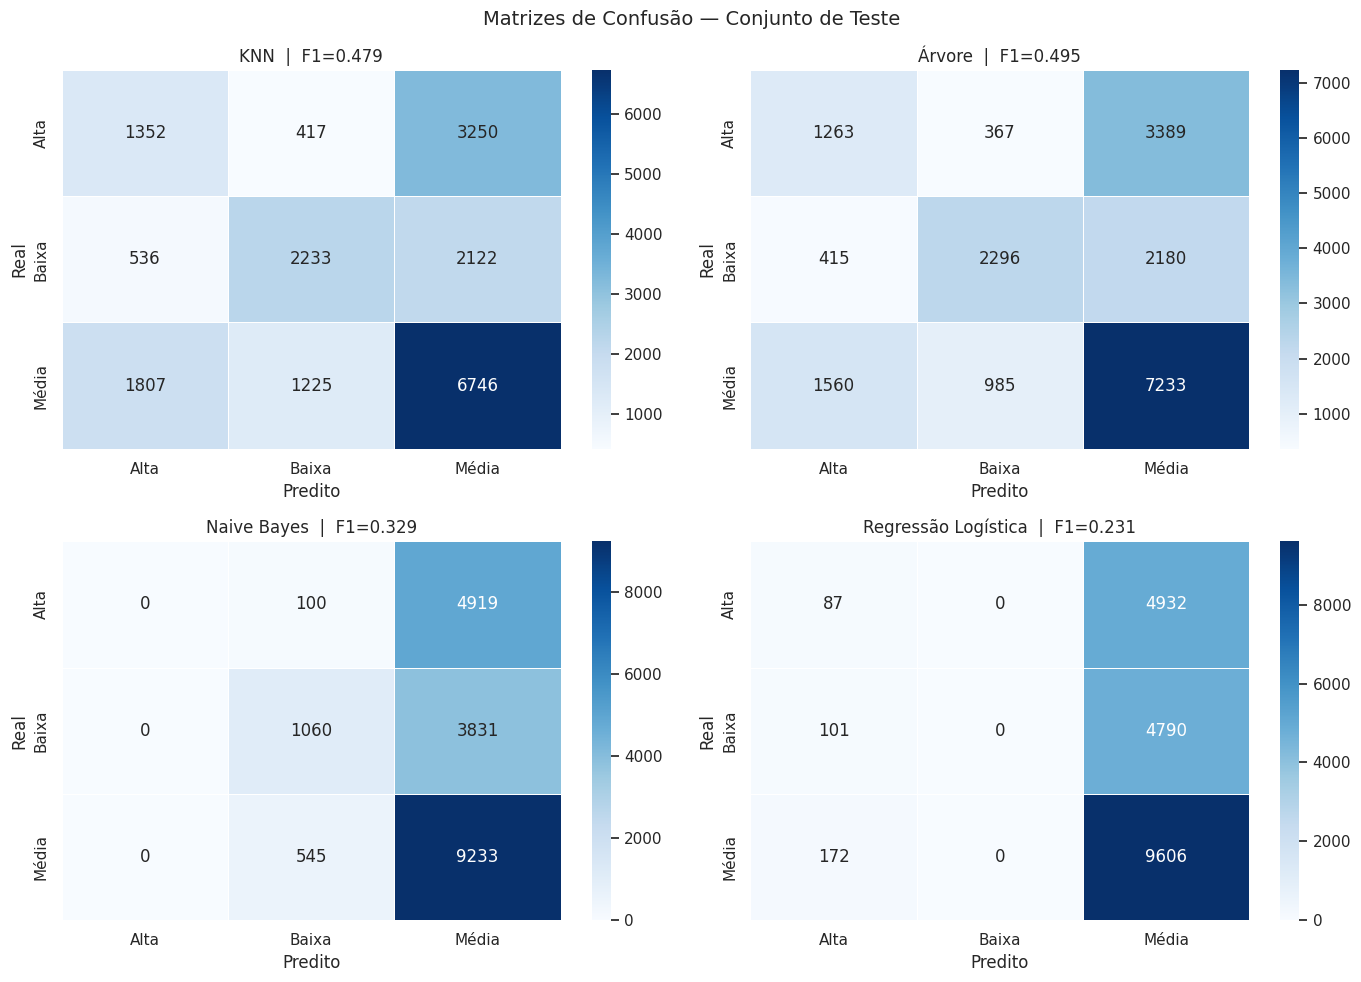

In [43]:
# Matrizes de confusão
classes = sorted(np.unique(y_test))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (nome, res) in enumerate(resultados_teste.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                xticklabels=classes, yticklabels=classes,
                cmap='Blues', linewidths=0.5)
    axes[idx].set_title(f'{nome}  |  F1={res["f1_macro"]:.3f}')
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14)
plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=120)
plt.show()

## 9. Exportação do Melhor Modelo

Selecionamos o modelo com maior **F1-macro no conjunto de teste** e o exportamos com `joblib`. O Pipeline completo (scaler + classificador) é exportado, garantindo que o pré-processamento seja parte integrante do artefato.

In [44]:
from pathlib import Path

melhor_nome   = max(resultados_teste, key=lambda n: resultados_teste[n]['f1_macro'])
melhor_modelo = melhores_modelos[melhor_nome]

print(f' Melhor modelo : {melhor_nome}')
print(f'   Acurácia     : {resultados_teste[melhor_nome]["accuracy"]:.4f}')
print(f'   F1-macro     : {resultados_teste[melhor_nome]["f1_macro"]:.4f}')

diretorio_model = Path('../model')
diretorio_model.mkdir(parents=True, exist_ok=True)

joblib.dump(melhor_modelo, '../model/modelo_popularidade.pkl')
print('\n Modelo exportado: modelo_popularidade.pkl')

 Melhor modelo : Árvore
   Acurácia     : 0.5482
   F1-macro     : 0.4948

 Modelo exportado: modelo_popularidade.pkl


## 10. Exportação dos Artefatos de Recomendação

Exportamos os artefatos do **sistema de recomendação por similaridade** (TF-IDF + similaridade de cosseno). O TF-IDF é ajustado sobre o dataset completo, o que é válido pois trata-se de um sistema **não supervisionado** — não há variável alvo, portanto não existe risco de leakage.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix

# COL_LINK já foi definido em code-07
colunas_rec = [c for c in [COL_TITULO, COL_AUTOR, COL_RATING, COL_COUNT, COL_LINK] if c is not None]
df_rec = df[colunas_rec].copy().reset_index(drop=True)

# Popularidade exibida na interface — usa percentis do treino
df_rec['popularidade'] = df_rec[COL_COUNT].apply(
    lambda n: classificar_popularidade(n, p25, p75)
)

# Campo textual combinado
titulo_col = COL_TITULO if COL_TITULO else ''
autor_col  = COL_AUTOR  if COL_AUTOR  else ''
if titulo_col and autor_col:
    df_rec['texto'] = (df_rec[titulo_col].fillna('') + ' ' + df_rec[autor_col].fillna('')).str.lower()
elif titulo_col:
    df_rec['texto'] = df_rec[titulo_col].fillna('').str.lower()
else:
    df_rec['texto'] = df_rec[autor_col].fillna('').str.lower()

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df_rec['texto'])

# Rating normalizado como feature complementar
rating_norm    = normalize(df_rec[[COL_RATING]].fillna(0).values)
rating_sparse  = csr_matrix(rating_norm)
feature_matrix = hstack([tfidf_matrix, rating_sparse])

# Exportação
joblib.dump(tfidf, 'tfidf_vetorizador.pkl')
joblib.dump(feature_matrix, 'feature_matrix.pkl')
df_rec.to_csv('goodreads_rec.csv', index=False)

# Metadados — inclui todos os parâmetros necessários para reproduzir o pipeline
metadata = {
    'col_titulo':      COL_TITULO,
    'col_autor':       COL_AUTOR,
    'col_rating':      COL_RATING,
    'col_count':       COL_COUNT,
    'col_paginas':     COL_PAGINAS,
    'col_link':        COL_LINK, # Agora COL_LINK terá o valor correto
    'features':        FEATURES,
    'p25':             float(p25),
    'p75':             float(p75),
    'mediana_paginas': float(mediana_paginas) if mediana_paginas is not None else None,
    'melhor_modelo':   melhor_nome,
    'f1_macro_teste':  float(resultados_teste[melhor_nome]['f1_macro']),
    'accuracy_teste':  float(resultados_teste[melhor_nome]['accuracy'])
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(' Artefatos exportados:')
for artefato in ['modelo_popularidade.pkl', 'tfidf_vetorizador.pkl',
                 'feature_matrix.pkl', 'goodreads_rec.csv', 'model_metadata.json']:
    print(f'   {artefato}')

 Artefatos exportados:
   modelo_popularidade.pkl
   tfidf_vetorizador.pkl
   feature_matrix.pkl
   goodreads_rec.csv
   model_metadata.json


In [ ]:
# Download de todos os artefatos
#from google.colab import files

#for artefato in [
#    'modelo_popularidade.pkl',
#    'tfidf_vetorizador.pkl',
#    'feature_matrix.pkl',
#    'goodreads_rec.csv',
#    'model_metadata.json'
#]:
#    files.download(artefato)
#    print(f' {artefato}')

#print('\n Download concluído!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 modelo_popularidade.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 goodreads_rec.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 model_metadata.json

 Download concluído!


## 11. Considerações de Segurança

### Reflexão sobre Desenvolvimento de Software Seguro

#### Anonimização de Dados
O dataset Goodreads Books 100k contém apenas dados **públicos e não pessoais**. Caso o sistema fosse estendido para coletar histórico de leituras de usuários reais, seria necessário aplicar:
- **Pseudonimização**: substituição de identificadores por hashes (SHA-256 com salt) antes de qualquer processamento
- **k-Anonimato**: garantia de que cada perfil se assemelhe a pelo menos *k* outros perfis no dataset
- **Differential Privacy**: adição de ruído controlado (mecanismo de Laplace) às agregações para proteção individual

#### Sanitização de Inputs
Toda entrada textual do usuário deve ser sanitizada antes de qualquer processamento: truncada a um comprimento máximo, convertida para lowercase e validada contra padrões maliciosos (injeção de comandos, XSS).

#### Segurança do Modelo
- Arquivos `.pkl` nunca devem ser expostos publicamente (risco de *model stealing* e *adversarial attacks*)
- Inputs numéricos devem ter seus ranges validados (ex.: rating ∈ [0, 5]) para prevenir ataques adversariais
- Em produção: autenticação JWT nas rotas da API

#### LGPD / GDPR
Se dados de usuários forem coletados para personalização:
- Obter consentimento explícito e documentado
- Implementar direito ao esquecimento (exclusão de dados)
- Manter logs de acesso com retenção limitada (máximo 90 dias)